In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tqdm as tq
from scipy.stats import spearmanr

In [9]:
arabidopsis_tomato_nm = pd.read_csv('C:\\Users\\mikep\\Data\\Data_for_review\\tomato_to_arabidopsis_ortholog_NM.csv')
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
1,4081_0:0062c9,3702_0:006584,10009at3193,LOC101249449,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
4,4081_0:0060db,3702_0:0018a2,10147at3193,LOC101260909,AT1G18450
...,...,...,...,...,...
53425,4081_0:003f8c,3702_0:003134,9942at3193,LOC101261051,AT3G59920
53426,4081_0:005b8a,3702_0:003134,9942at3193,LOC101259410,AT3G59920
53427,4081_0:000a73,3702_0:005540,9942at3193,GDI1,AT5G09550
53428,4081_0:003f8c,3702_0:005540,9942at3193,LOC101261051,AT5G09550


In [10]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'arabidopsis Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'tomato Symbol',)
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
5,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040
6,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120
...,...,...,...,...,...
53411,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750
53413,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380
53414,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790
53420,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440


In [73]:
arabi_csv_uncleaned = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\GSE94015_gene_readCount.txt",
    sep="\t",
)
arabi_csv = arabi_csv_uncleaned[
    [
        "Locus",
        "WtRL0h_rep1",
        "WtRL0h_rep2",
        "WtRL0h_rep3",
        "WtRL3h_rep1",
        "WtRL3h_rep2",
        "WtRL3h_rep3",
    ]
]

arabi_csv = arabi_csv.set_index('Locus')
arabi_csv

,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
Locus,,,,,,
AT1G01010,92,212,255,79,154,169
AT1G01020,120,288,219,219,354,597
AT1G01030,3,28,15,5,9,14
AT1G01040,889,2127,2189,1041,1788,1807
AT1G01046,12,51,37,8,26,19
...,...,...,...,...,...,...
ATMG01370,18,59,67,218,382,249
ATMG01380,13,8,14,104,136,107
ATMG01390,382,1046,4054,5581,8779,4796


In [166]:
arabi_csv = np.log2(arabi_csv + .01)

In [169]:
low_heat_tomato_1 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\low_heat_tomato\\tomato_no_heat_stress_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_tomato_2 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\low_heat_tomato\\tomato_no_heat_stress_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
low_heat_tomato_3 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\low_heat_tomato\\tomato_no_heat_stress_3ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)

low_heat_tomato = pd.DataFrame(
    data=zip(
        low_heat_tomato_1["Reads"],
        low_heat_tomato_2["Reads"],
        low_heat_tomato_3["Reads"],
    ),
    columns=["Tom Cold Rep 1", "Tom Cold Rep 2", "Tom Cold Rep 3"],
    index=low_heat_tomato_1.index,
)
low_heat_tomato

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3
LOC104645797,0,0,0
GAD3,400,322,552
LOC101263636,1838,1674,1865
sos1,400,391,332
LOC101263144,201,200,179
...,...,...,...
LyesC2p005,0,0,0
LyesC2p004,0,3,0
LyesC2t045,0,0,0
LyesC2p003,0,1,6


In [170]:
high_heat_tomato_rep_1 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\high_heat_tomato\\tomato_heat_stress_1ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_tomato_rep_2 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\high_heat_tomato\\tomato_heat_stress_2ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_tomato_rep_3 = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\Arabi_tomato_comparison\\high_heat_tomato\\tomato_heat_stress_3ReadsPerGene.out.tab",
    sep="\t",
    index_col=0,
    skiprows=4,
    header=None,
    names=["Reads", "Left Reads", "Right reads"],
)
high_heat_tomato = pd.DataFrame(
    data=zip(
        high_heat_tomato_rep_1["Reads"],
        high_heat_tomato_rep_2["Reads"],
        high_heat_tomato_rep_3["Reads"],
    ),
    columns=["Tom Hot Rep 1", "Tom Hot Rep 2", "Tom Hot Rep 3"],
    index=low_heat_tomato_1.index,
)

In [171]:
full_tomato = pd.concat([low_heat_tomato, high_heat_tomato], axis = 1)
full_tomato

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
LOC104645797,0,0,0,0,0,0
GAD3,400,322,552,879,462,743
LOC101263636,1838,1674,1865,444,383,379
sos1,400,391,332,904,648,702
LOC101263144,201,200,179,996,784,684
...,...,...,...,...,...,...
LyesC2p005,0,0,0,0,0,0
LyesC2p004,0,3,0,0,0,0
LyesC2t045,0,0,0,0,0,0
LyesC2p003,0,1,6,0,0,1


In [172]:
full_tomato = np.log2(full_tomato + .01)
full_tomato

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
LOC104645797,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856
GAD3,8.643892,8.330962,9.108551,9.779736,8.851780,9.537238
LOC101263636,10.843929,10.709092,10.864968,8.794448,8.581238,8.566092
sos1,8.643892,8.611062,8.375083,9.820195,9.339872,9.455348
LOC101263144,7.651123,7.643928,7.483896,9.960016,9.614728,9.417874
...,...,...,...,...,...,...
LyesC2p005,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856
LyesC2p004,-6.643856,1.589763,-6.643856,-6.643856,-6.643856,-6.643856
LyesC2t045,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856
LyesC2p003,-6.643856,0.014355,2.587365,-6.643856,-6.643856,0.014355


In [173]:
tomato_csv_mean

,Tomato Expression
LOC104645797,0.000000
GAD3,424.666667
LOC101263636,1792.333333
sos1,374.333333
LOC101263144,193.333333
...,...
LyesC2p005,0.000000
LyesC2p004,1.000000
LyesC2t045,0.000000
LyesC2p003,2.333333


In [174]:
arabi_csv_mean

,Arabidopsis Expression
Locus,
AT1G01010,186.333333
AT1G01020,209.000000
AT1G01030,15.333333
AT1G01040,1735.000000
AT1G01046,33.333333
...,...
ATMG01370,48.000000
ATMG01380,11.666667
ATMG01390,1827.333333


In [175]:
arabidopsis_tomato_nm

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200
2,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300
3,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910
5,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040
6,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120
...,...,...,...,...,...
53411,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750
53413,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380
53414,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790
53420,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440


In [176]:
arabidopsis_tomato_nm_merged_arabi = arabidopsis_tomato_nm.merge(how = 'inner', left_on = 'arabidopsis Symbol', right_on= 'Locus', right = arabi_csv, )

In [177]:
arabidopsis_tomato_nm_merged_both = arabidopsis_tomato_nm_merged_arabi.merge(how = 'inner', left_on = 'tomato Symbol', right_index = True, right = full_tomato )

In [178]:
arabidopsis_tomato_nm_merged_both

,tomato OrthoGene,arabidopsis OrthoGene,Orthogroup,tomato Symbol,arabidopsis Symbol,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
0,4081_0:002534,3702_0:006584,10009at3193,LOC101245541,AT5G42200,5.755155,6.523719,5.000451,5.357904,8.299254,6.768317,7.672496,6.658354,7.585038,8.124173,8.159922,8.087516
1,4081_0:0044e5,3702_0:001f5f,10092at3193,GPA1,AT2G26300,9.216770,10.258578,10.683003,9.405163,10.765709,10.655540,8.194806,8.103340,8.129335,8.400922,8.149798,8.124173
2,4081_0:0060db,3702_0:000e32,10147at3193,LOC101260909,AT1G73910,0.014355,1.589763,0.014355,3.460743,4.460087,1.007196,8.033478,8.675992,8.317458,9.643874,9.601789,9.681256
3,4081_0:001ce5,3702_0:000573,10228at3193,LOC101262196,AT1G49040,9.573666,10.596199,10.565112,8.764905,9.688268,9.965799,9.413649,9.596208,9.357574,10.716828,10.573657,10.288878
4,4081_0:00485f,3702_0:0012bf,10238at3193,LOC101260971,AT1G79120,1.589763,2.324811,3.171527,1.589763,4.858478,4.000901,2.587365,1.007196,0.014355,5.170326,5.087887,5.554896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10377,4081_0:001e35,3702_0:00121f,9828at3193,LOC101268561,AT1G74750,6.768317,7.983051,8.209502,6.629502,7.285495,7.900927,8.479821,8.810604,8.257435,8.527516,8.592494,7.994410
10378,4081_0:00467b,3702_0:0052b3,9836at3193,LOC101260957,AT5G11380,7.960060,8.413670,8.784668,7.924872,8.971572,9.071489,7.614783,7.499926,7.622125,9.603645,9.189849,9.149773
10379,4081_0:003e73,3702_0:001def,9877at3193,LOC101258079,AT2G42790,10.377221,11.105260,11.293477,10.909901,11.897471,11.675520,6.894939,6.755021,6.266974,6.087675,4.807870,5.833143
10380,4081_0:00201e,3702_0:00114d,9919at3193,LOC101252265,AT1G15440,6.459596,8.247975,8.422107,9.066116,9.428381,10.052582,5.209843,5.392661,3.808385,8.339895,8.266833,7.924872


In [179]:
shuffled_tomato = arabidopsis_tomato_nm_merged_both[["Tom Cold Rep 1", "Tom Cold Rep 2", "Tom Cold Rep 3", "Tom Hot Rep 1", "Tom Hot Rep 2", "Tom Hot Rep 3"]].sample(frac = 1)
shuffled_df = pd.concat([arabidopsis_tomato_nm_merged_both[['Orthogroup','WtRL0h_rep1','WtRL0h_rep2','WtRL0h_rep3','WtRL3h_rep1','WtRL3h_rep2','WtRL3h_rep3']], shuffled_tomato], axis = 1)
shuffled_df

,Orthogroup,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
0,10009at3193,5.755155,6.523719,5.000451,5.357904,8.299254,6.768317,7.672496,6.658354,7.585038,8.124173,8.159922,8.087516
1,10092at3193,9.216770,10.258578,10.683003,9.405163,10.765709,10.655540,8.194806,8.103340,8.129335,8.400922,8.149798,8.124173
2,10147at3193,0.014355,1.589763,0.014355,3.460743,4.460087,1.007196,8.033478,8.675992,8.317458,9.643874,9.601789,9.681256
3,10228at3193,9.573666,10.596199,10.565112,8.764905,9.688268,9.965799,9.413649,9.596208,9.357574,10.716828,10.573657,10.288878
4,10238at3193,1.589763,2.324811,3.171527,1.589763,4.858478,4.000901,2.587365,1.007196,0.014355,5.170326,5.087887,5.554896
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10377,9828at3193,6.768317,7.983051,8.209502,6.629502,7.285495,7.900927,8.479821,8.810604,8.257435,8.527516,8.592494,7.994410
10378,9836at3193,7.960060,8.413670,8.784668,7.924872,8.971572,9.071489,7.614783,7.499926,7.622125,9.603645,9.189849,9.149773
10379,9877at3193,10.377221,11.105260,11.293477,10.909901,11.897471,11.675520,6.894939,6.755021,6.266974,6.087675,4.807870,5.833143
10380,9919at3193,6.459596,8.247975,8.422107,9.066116,9.428381,10.052582,5.209843,5.392661,3.808385,8.339895,8.266833,7.924872


In [180]:
zero_counts = (shuffled_df.drop(columns=["Orthogroup"]) == 0).sum(axis=1)
shuffled_df = shuffled_df.loc[zero_counts <= 1].copy()
shuffled_df

,Orthogroup,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
0,10009at3193,5.755155,6.523719,5.000451,5.357904,8.299254,6.768317,7.672496,6.658354,7.585038,8.124173,8.159922,8.087516
1,10092at3193,9.216770,10.258578,10.683003,9.405163,10.765709,10.655540,8.194806,8.103340,8.129335,8.400922,8.149798,8.124173
2,10147at3193,0.014355,1.589763,0.014355,3.460743,4.460087,1.007196,8.033478,8.675992,8.317458,9.643874,9.601789,9.681256
3,10228at3193,9.573666,10.596199,10.565112,8.764905,9.688268,9.965799,9.413649,9.596208,9.357574,10.716828,10.573657,10.288878
4,10238at3193,1.589763,2.324811,3.171527,1.589763,4.858478,4.000901,2.587365,1.007196,0.014355,5.170326,5.087887,5.554896
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10377,9828at3193,6.768317,7.983051,8.209502,6.629502,7.285495,7.900927,8.479821,8.810604,8.257435,8.527516,8.592494,7.994410
10378,9836at3193,7.960060,8.413670,8.784668,7.924872,8.971572,9.071489,7.614783,7.499926,7.622125,9.603645,9.189849,9.149773
10379,9877at3193,10.377221,11.105260,11.293477,10.909901,11.897471,11.675520,6.894939,6.755021,6.266974,6.087675,4.807870,5.833143
10380,9919at3193,6.459596,8.247975,8.422107,9.066116,9.428381,10.052582,5.209843,5.392661,3.808385,8.339895,8.266833,7.924872


In [181]:
## genewise correlations
list_of_genewise_correlations = []
for row in shuffled_df.iterrows():
    arabi_array = row[1][['WtRL0h_rep1','WtRL0h_rep2','WtRL0h_rep3','WtRL3h_rep1','WtRL3h_rep2','WtRL3h_rep3']].values
    tomato_array = row[1][['Tom Cold Rep 1', 'Tom Cold Rep 2', 'Tom Cold Rep 3', 'Tom Hot Rep 1', 'Tom Hot Rep 2', 'Tom Hot Rep 3']].values
    correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
    list_of_genewise_correlations.append(correlation[0])


C:\Users\mikep\AppData\Local\Temp\ipykernel_6876\1761535133.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
C:\Users\mikep\AppData\Local\Temp\ipykernel_6876\1761535133.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
C:\Users\mikep\AppData\Local\Temp\ipykernel_6876\1761535133.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
C:\Users\mikep\AppData\Local\Temp\ipykernel_6876\1761535133.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
C:\Users\mikep\AppData\Local\Temp\ipykernel_6876\1761535133.py:6: Consta

In [182]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean

In [183]:
og_groups = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\og_2_Genes_with_ncbi_symbol.csv"
)
og_groups

,Orthogroup,Gene,Species,Ortholevel,Orthodb Gene,Symbol
0,100007at3193,4558_0:003a4f,4558,3193,4558_0:003a4f,LOC110434333
1,100007at3193,4577_0:004254,4577,3193,4577_0:004254,LOC100276500
2,100007at3193,4577_0:004e43,4577,3193,4577_0:004e43,LOC100275058
3,100067at3193,4558_0:00439a,4558,3193,4558_0:00439a,LOC8071983
4,100085at3193,4558_0:002fd8,4558,3193,4558_0:002fd8,LOC8086335
...,...,...,...,...,...,...
502887,9969at3193,15368_0:000e9a,15368,3193,15368_0:000e9a,LOC100834561
502888,99917at3193,39947_0:006297,39947,3193,39947_0:006297,LOC107276177
502889,99917at3193,39947_0:00634f,39947,3193,39947_0:00634f,LOC9269479
502890,99917at3193,39947_0:006629,39947,3193,39947_0:006629,LOC9269626


In [184]:
ncbi_mapping = pd.read_csv(
    "C:\\Users\\mikep\\git\\Family_level_coexpression\\Data_for_tutorial\\merged_ncbi_to_orthodb_fixed_non_genesymbol_updated_poplar.csv"
)

In [199]:
tomato_og = get_ncbi_clean_og2gene_for_species(
    4081, og_groups, ncbi_mapping=ncbi_mapping
)

In [200]:
arabi_og = get_ncbi_clean_og2gene_for_species(
    3702, og_groups, ncbi_mapping=ncbi_mapping
)

In [201]:
list_of_non_single_gene_groups_tomato = pd.Series(tomato_og['Orthogroup'].value_counts().loc[tomato_og['Orthogroup'].value_counts() >3])
list_of_non_single_gene_groups_arabi = pd.Series(arabi_og['Orthogroup'].value_counts().loc[arabi_og['Orthogroup'].value_counts() >3])
tomato_og = tomato_og.loc[tomato_og['Orthogroup'].isin(list_of_non_single_gene_groups_tomato.index)]
arabi_og = arabi_og.loc[arabi_og['Orthogroup'].isin(list_of_non_single_gene_groups_arabi.index)]

In [202]:
arabi_og

,3702 OrthoGene,Orthogroup,Symbol
17,3702_0:000421,10950at3193,AT1G23550
18,3702_0:000a44,10950at3193,AT1G70440
19,3702_0:000d1e,10950at3193,AT1G32230
20,3702_0:00299f,10950at3193,AT2G35510
21,3702_0:006a79,10950at3193,AT5G62520
...,...,...,...
25971,3702_0:006362,9601at3193,AT5G08390
25972,3702_0:00154a,9609at3193,AT1G10657
25973,3702_0:003ef5,9609at3193,AT3G28990
25974,3702_0:004120,9609at3193,AT3G55240


In [203]:
arabi_og['Orthogroup'] = arabi_og['Orthogroup'].sample(frac = 1).values
arabi_og

,3702 OrthoGene,Orthogroup,Symbol
17,3702_0:000421,879536at3193,AT1G23550
18,3702_0:000a44,877894at3193,AT1G70440
19,3702_0:000d1e,119523at3193,AT1G32230
20,3702_0:00299f,115882at3193,AT2G35510
21,3702_0:006a79,112624at3193,AT5G62520
...,...,...,...
25971,3702_0:006362,115361at3193,AT5G08390
25972,3702_0:00154a,120131at3193,AT1G10657
25973,3702_0:003ef5,757868at3193,AT3G28990
25974,3702_0:004120,37189at3193,AT3G55240


In [204]:
tomato_og['Orthogroup'] = tomato_og['Orthogroup'].sample(frac = 1).values
tomato_og


,4081 OrthoGene,Orthogroup,Symbol
14,4081_0:0007ed,125634at3193,LOC101248910
15,4081_0:001c07,877894at3193,LOC101245634
16,4081_0:00241b,126250at3193,LOC101250212
17,4081_0:0025bf,876628at3193,LOC101249914
18,4081_0:0028d1,1844at3193,LOC101249263
...,...,...,...
23874,4081_0:005923,886892at3193,LOC101267379
23884,4081_0:002d37,681378at3193,LOC101266225
23885,4081_0:002f0d,873443at3193,LOC101248387
23886,4081_0:004a7c,47047at3193,LOC101246275


In [205]:
dict_version = arabi_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
arabi_csv_ortho = arabi_csv.groupby(by = true_dict).mean()

In [206]:
arabi_csv_ortho

,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
Locus,,,,,,
10950at3193,4.296825,7.155350,5.467850,5.738278,6.899787,7.202641
109895at3193,2.992935,3.593347,4.326875,2.894244,3.267965,3.423206
110016at3193,-1.575816,-1.131474,-0.030776,-0.024170,2.131489,1.553946
110108at3193,-1.427627,-2.672688,-0.904676,-3.130523,-1.698124,-2.569229
110263at3193,-4.280539,-3.960814,-3.471739,-4.086351,-1.587386,-3.732779
...,...,...,...,...,...,...
890074at3193,1.496153,1.810339,1.066553,0.706184,1.394111,1.119858
8999at3193,3.444931,3.751559,3.719099,2.863911,0.624550,5.275998
9379at3193,5.595815,5.944243,6.727869,4.644155,3.972304,5.972538


In [207]:
dict_version = tomato_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
combined_tomato_ortho = full_tomato.groupby(by = true_dict).mean()

In [208]:
combined_tomato_ortho
shuffled_tomato_ortho  = combined_tomato_ortho.copy()
combined_tomato_ortho

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3
10950at3193,5.348986,5.597929,5.453687,3.878232,4.228336,4.638179
109895at3193,-1.895986,-1.720962,-1.816829,-2.874088,-1.134145,-2.985711
109997at3193,5.949438,5.486918,5.824273,6.294614,6.865556,6.252480
110108at3193,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856
110152at3193,3.141998,3.225742,4.600866,1.883906,4.334908,4.621923
...,...,...,...,...,...,...
889993at3193,1.623512,1.445643,1.846329,2.795363,1.271712,1.385895
889996at3193,-2.844097,-2.733275,-2.921174,-1.433947,-1.612153,-1.668965
9353at3193,3.752590,5.297863,3.207169,5.015047,4.512179,4.523299
9499at3193,1.903130,1.863600,1.816945,1.988413,1.946147,1.890377


In [209]:
combined_shuffled_ortho = combined_tomato_ortho.merge(right = arabi_csv_ortho, left_index = True, right_index = True)
combined_shuffled_ortho

,Tom Cold Rep 1,Tom Cold Rep 2,Tom Cold Rep 3,Tom Hot Rep 1,Tom Hot Rep 2,Tom Hot Rep 3,WtRL0h_rep1,WtRL0h_rep2,WtRL0h_rep3,WtRL3h_rep1,WtRL3h_rep2,WtRL3h_rep3
10950at3193,5.348986,5.597929,5.453687,3.878232,4.228336,4.638179,4.296825,7.155350,5.467850,5.738278,6.899787,7.202641
109895at3193,-1.895986,-1.720962,-1.816829,-2.874088,-1.134145,-2.985711,2.992935,3.593347,4.326875,2.894244,3.267965,3.423206
110108at3193,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856,-6.643856,-1.427627,-2.672688,-0.904676,-3.130523,-1.698124,-2.569229
110263at3193,3.821763,2.254713,2.441022,2.113956,2.493698,2.079931,-4.280539,-3.960814,-3.471739,-4.086351,-1.587386,-3.732779
110743at3193,5.643562,5.494688,5.416418,2.768433,2.753653,3.025553,-6.643856,-3.982667,-4.979303,-4.979303,-2.817439,-4.979303
...,...,...,...,...,...,...,...,...,...,...,...,...
889911at3193,3.282375,3.274654,2.955056,3.412061,3.231770,2.959194,2.183931,3.318542,4.305959,2.575177,3.079236,3.056376
889965at3193,4.381208,4.079941,3.931491,4.462625,4.266104,3.702881,3.880622,7.781301,6.781200,4.720941,8.353119,5.938349
889988at3193,4.445941,4.568570,4.548122,5.722395,5.562562,5.531773,-0.660001,-0.000129,0.309904,-2.698529,-0.380887,-2.473088
889993at3193,1.623512,1.445643,1.846329,2.795363,1.271712,1.385895,1.374933,-0.653208,-0.812456,1.815833,1.522435,1.089572


In [210]:
### orthowise correlations
list_of_orthowise_correlations = []
for row in combined_shuffled_ortho.iterrows():
    arabi_array = row[1][['WtRL0h_rep1','WtRL0h_rep2','WtRL0h_rep3','WtRL3h_rep1','WtRL3h_rep2','WtRL3h_rep3']].values
    tomato_array = row[1][['Tom Cold Rep 1', 'Tom Cold Rep 2', 'Tom Cold Rep 3', 'Tom Hot Rep 1', 'Tom Hot Rep 2', 'Tom Hot Rep 3']].values
    correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')
    list_of_orthowise_correlations.append(correlation[0])

C:\Users\mikep\AppData\Local\Temp\ipykernel_6876\3083016377.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(arabi_array, tomato_array, nan_policy='omit')


In [211]:
orthowise_pd = pd.DataFrame(data = list_of_orthowise_correlations, columns = ['Correlation'])
orthowise_pd['Type']= 'Orthowise'
genewise_pd = pd.DataFrame(data = list_of_genewise_correlations, columns = ['Correlation'])
genewise_pd['Type'] = 'Genewise'
plotting_df = pd.concat([orthowise_pd, genewise_pd], axis = 0)
plotting_df = plotting_df.reset_index(drop = True)
plotting_df

,Correlation,Type
0,-0.028571,Orthowise
1,0.314286,Orthowise
2,NaN,Orthowise
3,-0.028571,Orthowise
4,-0.576818,Orthowise
...,...,...
10640,-0.142857,Genewise
10641,0.028571,Genewise
10642,-0.828571,Genewise
10643,0.600000,Genewise


<Axes: xlabel='Correlation', ylabel='Probability'>

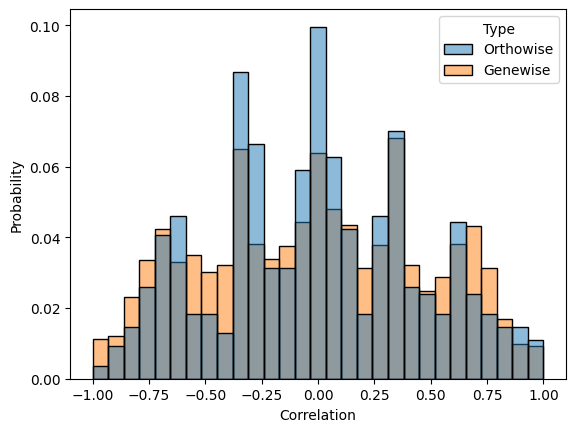

In [212]:
sns.histplot(plotting_df, x = 'Correlation', hue = 'Type', common_norm = False, stat = 'probability')

In [139]:
list_of_orthowise_correlations

[np.float64(0.4285714285714286),
 np.float64(-0.942857142857143),
 np.float64(0.6),
 np.float64(0.08571428571428573),
 np.float64(-0.7142857142857143),
 np.float64(-0.2),
 np.float64(0.4285714285714286),
 np.float64(-0.6),
 np.float64(0.7142857142857143),
 np.float64(0.2571428571428572),
 np.float64(0.4285714285714286),
 np.float64(0.2),
 np.float64(-0.6571428571428573),
 np.float64(0.3714285714285715),
 np.float64(-0.7714285714285715),
 np.float64(0.7714285714285715),
 np.float64(0.3142857142857143),
 np.float64(-0.7142857142857143),
 np.float64(-0.11595420713048968),
 np.float64(0.942857142857143),
 np.float64(-0.3714285714285715),
 np.float64(-0.6),
 np.float64(-0.14285714285714288),
 np.float64(-0.2),
 np.float64(-0.2),
 np.float64(-0.48571428571428577),
 np.float64(0.8285714285714287),
 np.float64(-0.2571428571428572),
 np.float64(0.4285714285714286),
 np.float64(-0.7714285714285715),
 np.float64(-0.6571428571428573),
 np.float64(0.08571428571428573),
 np.float64(-0.82857142857142